# Round 3 Manual - Clean Optimum vs Robust Hedge

This notebook searches the two-bid Bio-Pods problem on the real discrete reserve grid. It first finds the clean no-penalty optimum, then stress-tests the answer against different values of the global average second bid.

That is the whole round: the pretty answer was `751 / 836`, but the more robust answer we chose was `756 / 846`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

reserves = np.arange(670, 921, 5)
SELL_VALUE = 920

def penalty(b2, avg_b2):
    if b2 > avg_b2:
        return 1.0
    return ((920 - avg_b2) / (920 - b2)) ** 3

def expected_profit(b1, b2, avg_b2=-10**9):
    total = 0.0
    pen = penalty(b2, avg_b2)
    for r in reserves:
        if b1 > r:
            total += SELL_VALUE - b1
        elif b2 > r:
            total += (SELL_VALUE - b2) * pen
    return total / len(reserves)

best = None
for b1 in range(671, 920):
    for b2 in range(b1 + 1, 920):
        val = expected_profit(b1, b2)
        if best is None or val > best[0]:
            best = (val, b1, b2)
print("no-penalty best: b1=%s b2=%s expected=%.4f" % (best[1], best[2], best[0]))
for pair in [(751, 836), (751, 841), (756, 846), (756, 851), (766, 871)]:
    print("pair %s/%s no-penalty expected %.4f" % (pair[0], pair[1], expected_profit(*pair)))


no-penalty best: b1=751 b2=836 expected=84.3333
pair 751/836 no-penalty expected 84.3333
pair 751/841 no-penalty expected 84.2157
pair 756/846 no-penalty expected 84.0000
pair 756/851 no-penalty expected 83.5882
pair 766/871 no-penalty expected 80.5686


In [2]:
avgs = range(820, 876)
rows = []
for avg in avgs:
    best = None
    for b1 in range(671, 920):
        for b2 in range(b1 + 1, 920):
            val = expected_profit(b1, b2, avg)
            if best is None or val > best[0]:
                best = (val, b1, b2)
    rows.append((avg, best[1], best[2], best[0]))

regimes = []
start = rows[0][0]
last_pair = rows[0][1:3]
last_val = rows[0][3]
for avg, b1, b2, val in rows[1:]:
    if (b1, b2) != last_pair:
        regimes.append((start, avg - 1, last_pair[0], last_pair[1], last_val))
        start = avg
        last_pair = (b1, b2)
    last_val = val
regimes.append((start, rows[-1][0], last_pair[0], last_pair[1], last_val))

for lo, hi, b1, b2, val in regimes:
    print("avg %s..%s -> b1=%s b2=%s representative_EV=%.4f" % (lo, hi, b1, b2, val))


avg 820..836 -> b1=751 b2=836 representative_EV=84.3333
avg 837..841 -> b1=751 b2=841 representative_EV=84.2157
avg 842..846 -> b1=756 b2=846 representative_EV=84.0000
avg 847..847 -> b1=756 b2=847 representative_EV=83.6471
avg 848..851 -> b1=756 b2=851 representative_EV=83.5882
avg 852..852 -> b1=761 b2=852 representative_EV=83.2353
avg 853..856 -> b1=761 b2=856 representative_EV=83.0784
avg 857..857 -> b1=761 b2=857 representative_EV=82.7059
avg 858..861 -> b1=761 b2=861 representative_EV=82.3725
avg 862..862 -> b1=766 b2=862 representative_EV=82.0000
avg 863..863 -> b1=766 b2=863 representative_EV=81.6275
avg 864..866 -> b1=766 b2=866 representative_EV=81.5686
avg 867..867 -> b1=766 b2=867 representative_EV=81.1765
avg 868..868 -> b1=766 b2=868 representative_EV=80.7843
avg 869..871 -> b1=766 b2=871 representative_EV=80.5686
avg 872..872 -> b1=771 b2=872 representative_EV=80.1765
avg 873..873 -> b1=771 b2=873 representative_EV=79.7843
avg 874..875 -> b1=771 b2=876 representative_EV=

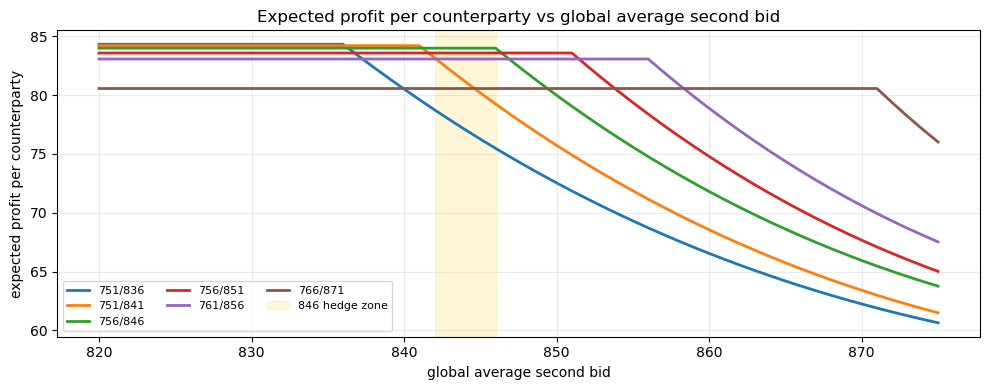

In [3]:
candidates = [(751, 836), (751, 841), (756, 846), (756, 851), (761, 856), (766, 871)]
avg_grid = np.arange(820, 876)
fig, ax = plt.subplots(figsize=(10, 4))
for pair in candidates:
    vals = [expected_profit(pair[0], pair[1], avg) for avg in avg_grid]
    ax.plot(avg_grid, vals, label=f"{pair[0]}/{pair[1]}", lw=2)
ax.axvspan(842, 846, color="#fde68a", alpha=0.35, label="846 hedge zone")
ax.set_title("Expected profit per counterparty vs global average second bid")
ax.set_xlabel("global average second bid")
ax.set_ylabel("expected profit per counterparty")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()
